In [62]:
import pandas as pd
import numpy as np

In [63]:
df = pd.read_csv('Churn_Modelling.csv')

In [64]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [65]:
df.shape

(10000, 14)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [67]:
df.duplicated().sum()

0

In [68]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [69]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [70]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [71]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [72]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [73]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [74]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [75]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=['Exited'])
y = df['Exited']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1)

In [76]:
x_train.shape

(8000, 11)

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [78]:
x_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [79]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [80]:
model = Sequential()
# Input layer
# Dense creates a fully connected layer(or dense layer), 3 is the number of neurons, sigmoid is the activation function, input_dim is the number of features in the input data
# model.add(Dense(3,activation='sigmoid',input_dim=11))
# Output layer
# model.add(Dense(1,activation='sigmoid'))

In [81]:
# Experimenting
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\godsc\anaconda3\envs\tf-gpu\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
# model summary gives us a summary of the model architecture, including the number of layers, the number of parameters in each layer, and the total number of parameters in the model.
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# compile the model, loss is the loss function, optimizer is the optimization algorithm used to update the weights of the model during training
# model.compile(loss='binary_crossentropy',optimizer='Adam')
# Adding accuracy metric inside will also showcase you accuracy along with loss
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [84]:
# model.fit(x_train_scaled,y_train,epochs=100)
# here we'll use validation_split which will split the training data into training and validation data, and will use the validation data to evaluate the model during training
# this is also a good method to evaluate the model during training and to prevent overfitting
history = model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)
# save this model to plot graphs later

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7808 - loss: 0.5212 - val_accuracy: 0.7975 - val_loss: 0.4789
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8008 - loss: 0.4473 - val_accuracy: 0.8069 - val_loss: 0.4442
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8186 - loss: 0.4237 - val_accuracy: 0.8156 - val_loss: 0.4228
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8330 - loss: 0.4071 - val_accuracy: 0.8275 - val_loss: 0.4047
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8413 - loss: 0.3911 - val_accuracy: 0.8394 - val_loss: 0.3864
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8508 - loss: 0.3766 - val_accuracy: 0.8438 - val_loss: 0.3722
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8550 - loss: 0.3656 - val_accuracy: 0.8512 - val_loss: 0.3640
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8575 - loss: 0.3577 - val_accu

In [85]:
# get_weights() returns the weights of the layer
# Here we get the total weights of layer 0
model.layers[0].get_weights()

[array([[ 1.60364658e-01, -2.39274085e-01,  5.74701607e-01,
         -1.39212832e-01, -4.29203734e-02, -5.13312995e-01,
          1.28241509e-01,  1.32999480e-01,  8.05015638e-02,
          3.23679775e-01,  3.25572881e-04],
        [ 2.36733451e-01, -3.08948934e-01,  5.09409368e-01,
         -7.15106010e-01,  9.47340727e-02, -2.26467311e-01,
          1.36129820e+00, -5.55338502e-01,  3.76308560e-01,
         -6.10733151e-01, -1.30060866e-01],
        [-2.68576480e-02,  8.02168548e-02, -1.13623671e-01,
          3.91976833e-02,  2.34033749e-01,  5.08186221e-01,
          9.39007327e-02, -1.50567666e-01, -6.27836436e-02,
          1.39717594e-01,  2.54196525e-01],
        [ 4.71384615e-01, -5.46628982e-02,  2.69865394e-01,
         -7.23530650e-02, -3.51635605e-01, -7.83982038e-01,
          3.91958244e-02,  7.61330011e-06, -1.85478151e-01,
          1.31414202e-03, -1.24838978e-01],
        [ 9.61699307e-01,  3.23224068e-01, -8.15002993e-03,
          3.00126463e-01,  5.91067523e-02,  

In [86]:
model.layers[1].get_weights()

[array([[ 0.17609651, -0.39336753, -0.00705143,  0.1269139 ,  0.5563607 ,
          1.3803035 ,  0.4710834 ,  0.48321232, -0.03690138, -0.2340673 ,
         -0.7273606 ],
        [-0.6572348 ,  0.48056754,  0.32036862,  0.46075907,  0.13117108,
         -0.30765945,  0.2743538 ,  0.20881715, -2.320534  ,  0.12862964,
         -0.7259908 ],
        [ 0.09583126,  0.31999496,  0.65965915, -0.6521065 ,  0.09459572,
          0.05185355, -0.00825749,  0.08516262, -0.17277229,  0.3611487 ,
         -0.18859002],
        [-0.3563012 ,  0.6518879 ,  0.18228115, -0.252455  ,  0.280248  ,
         -0.67237455,  0.44745734, -0.42293292, -0.59135664, -0.49422753,
          0.32015765],
        [ 0.09140048,  0.14138961,  0.04880838,  0.04389011, -0.69129133,
         -0.50159484, -0.379579  , -0.22125769, -0.09876139,  0.02784628,
          0.19259775],
        [ 0.5074254 , -0.54471177,  0.18347238,  0.43092215,  0.34222308,
          0.56939733,  0.35302147,  0.5295898 , -1.0155486 ,  0.3958348

In [87]:
y_log = model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [88]:
# The above will predict the probabilities of the output
# Now we need to decide a threshold to convert the probabilities into binary output (0 or 1)

In [89]:
# Let's say we choose a threshold of 0.5
y_pred = np.where(y_log>0.5,1,0)

In [90]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8615

In [91]:
# What we can do to improve the accuracy
# 1. Increase the number of neurons in the hidden layer
# 2. Add more hidden layers
# 3. Increase the number of epochs
# 4. Change the activation function to relu

In [92]:
# Lets experiment above points and see how it affects the accuracy

In [93]:
# Draw the graph
import matplotlib.pyplot as plt

In [94]:
# This provide a dictionary of the history of the training process, including the loss and accuracy values for each epoch
history.history

{'accuracy': [0.7807812690734863,
  0.80078125,
  0.8185937404632568,
  0.8329687714576721,
  0.8412500023841858,
  0.850781261920929,
  0.8550000190734863,
  0.8575000166893005,
  0.860156238079071,
  0.8596875071525574,
  0.8604687452316284,
  0.8612499833106995,
  0.8606250286102295,
  0.8615624904632568,
  0.8606250286102295,
  0.8631250262260437,
  0.8596875071525574,
  0.8618749976158142,
  0.8615624904632568,
  0.8618749976158142,
  0.8607812523841858,
  0.8614062666893005,
  0.8604687452316284,
  0.8620312213897705,
  0.8612499833106995,
  0.8628125190734863,
  0.8626562356948853,
  0.8626562356948853,
  0.86328125,
  0.8615624904632568,
  0.8606250286102295,
  0.8618749976158142,
  0.8620312213897705,
  0.8629687428474426,
  0.8643749952316284,
  0.8645312786102295,
  0.862500011920929,
  0.8646875023841858,
  0.8656250238418579,
  0.8645312786102295,
  0.8651562333106995,
  0.8646875023841858,
  0.8629687428474426,
  0.8643749952316284,
  0.8620312213897705,
  0.8628125190734

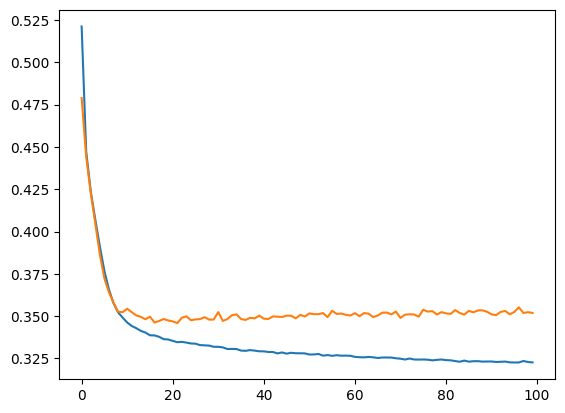

In [95]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

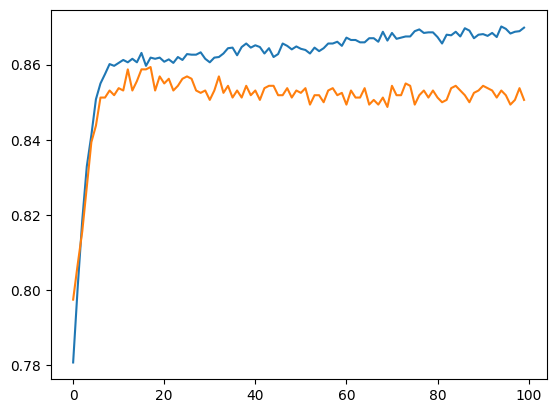

In [96]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])